### Error Rates (accross all errors) per SuT

<Figure size 1000x600 with 0 Axes>

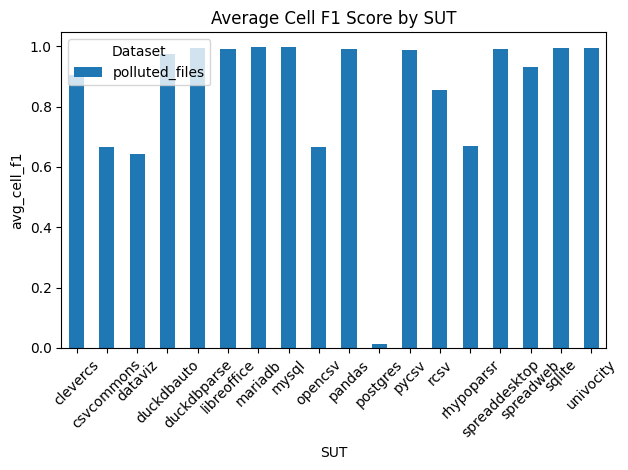

<Figure size 1000x600 with 0 Axes>

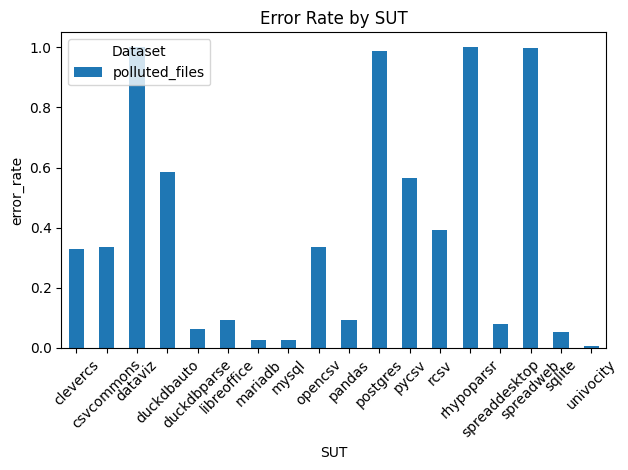

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV
df = pd.read_csv("sut_error_summary.csv")

# Optional: keep only summary rows
summary_df = df[df["pollution_group"] == "ALL"]

# -----------------------------
# Plot 1: Average Cell F1 Score
# -----------------------------
pivot_f1 = summary_df.pivot(
    index="sut",
    columns="dataset",
    values="avg_cell_f1"
)

plt.figure(figsize=(10, 6))
pivot_f1.plot(kind="bar")

plt.title("Average Cell F1 Score by SUT")
plt.ylabel("avg_cell_f1")
plt.xlabel("SUT")
plt.xticks(rotation=45)
plt.legend(title="Dataset")
plt.tight_layout()

plt.show()

# -----------------------------
# Plot 2: Error Rate
# -----------------------------
pivot_error = summary_df.pivot(
    index="sut",
    columns="dataset",
    values="error_rate"
)

plt.figure(figsize=(10, 6))
pivot_error.plot(kind="bar")

plt.title("Error Rate by SUT")
plt.ylabel("error_rate")
plt.xlabel("SUT")
plt.xticks(rotation=45)
plt.legend(title="Dataset")
plt.tight_layout()

plt.show()

### Error Rates for Top 5 Best Performing SuTs

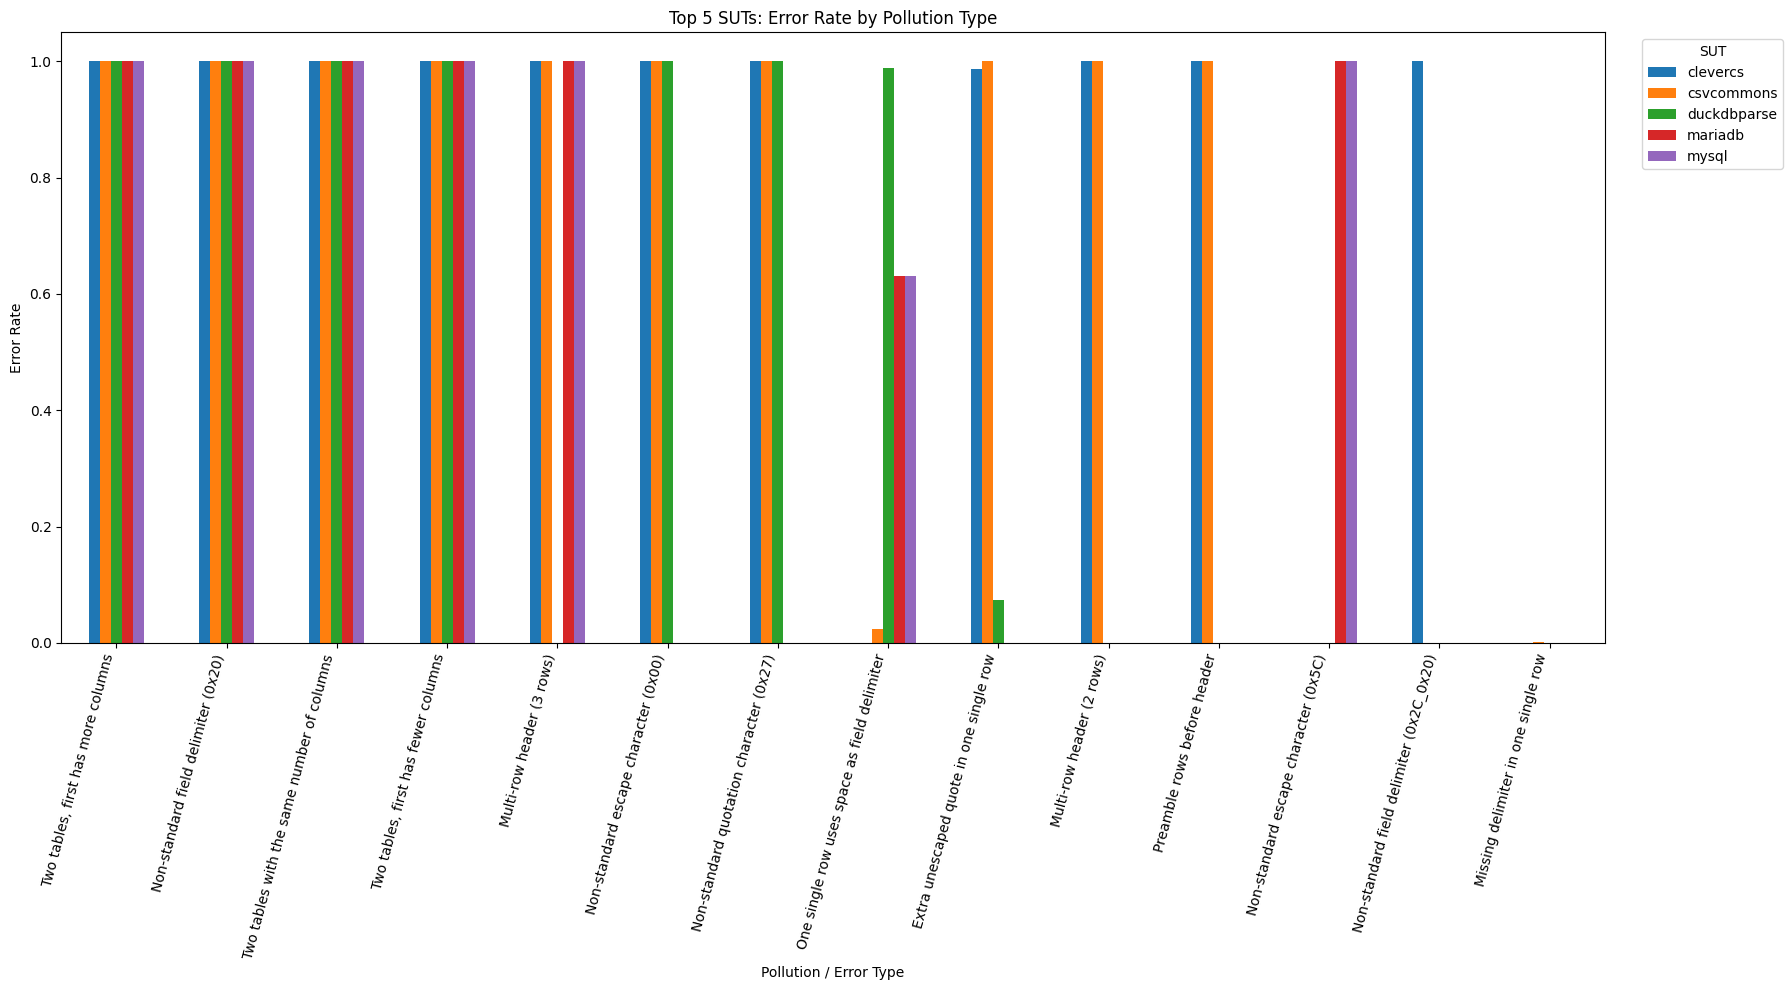

In [ ]:
# Load CSV
df = pd.read_csv("sut_error_summary.csv")

# Remove aggregate rows
df = df[df["pollution_group"] != "ALL"]

# -----------------------------------
# Select Top 5 SUTs
# -----------------------------------
top_suts = (
    df.groupby("sut")["error_rate"]
    .mean()
    .sort_values()
    .head(5)
    .index
)

df = df[df["sut"].isin(top_suts)]

# -----------------------------------
# Pivot table
# -----------------------------------
pivot = df.pivot_table(
    index="pollution_group",
    columns="sut",
    values="error_rate",
    aggfunc="mean"
)

# -----------------------------------
# Remove pollution groups with no errors
# (all values are 0)
# -----------------------------------
pivot = pivot[(pivot > 0).any(axis=1)]

# -----------------------------------
# Sort by average error severity
# -----------------------------------
pivot["mean_error"] = pivot.mean(axis=1)
pivot = pivot.sort_values("mean_error", ascending=False)
pivot = pivot.drop(columns="mean_error")

# -----------------------------------
# Plot
# -----------------------------------
ax = pivot.plot(
    kind="bar",
    figsize=(18, 10)
)

plt.title("Top 5 SUTs: Error Rate by Pollution Type")
plt.ylabel("Error Rate")
plt.xlabel("Pollution / Error Type")

plt.xticks(rotation=75, ha="right")

plt.legend(
    title="SUT",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
#plt.savefig("error_rate_by_pollution.png", dpi=300)
plt.show()

### Per System Error Analysis

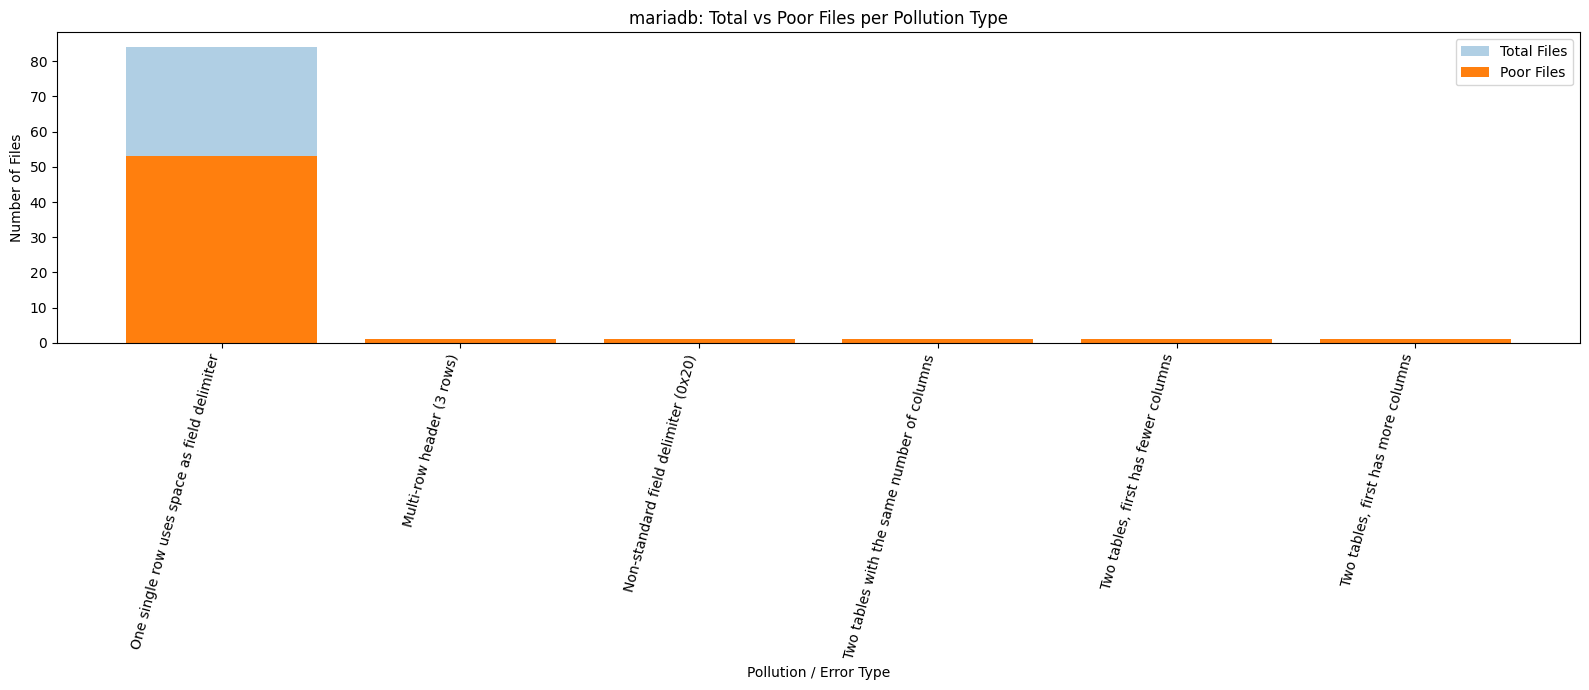

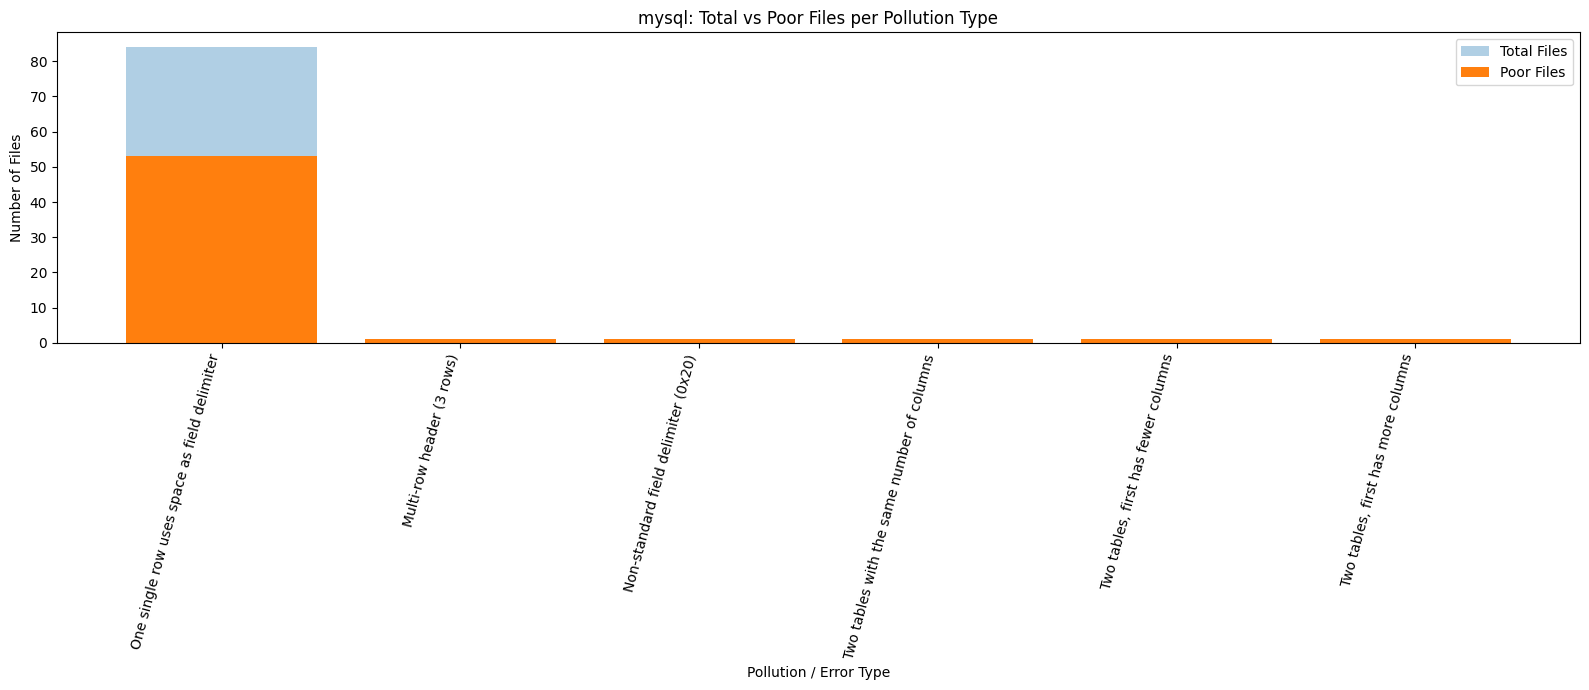

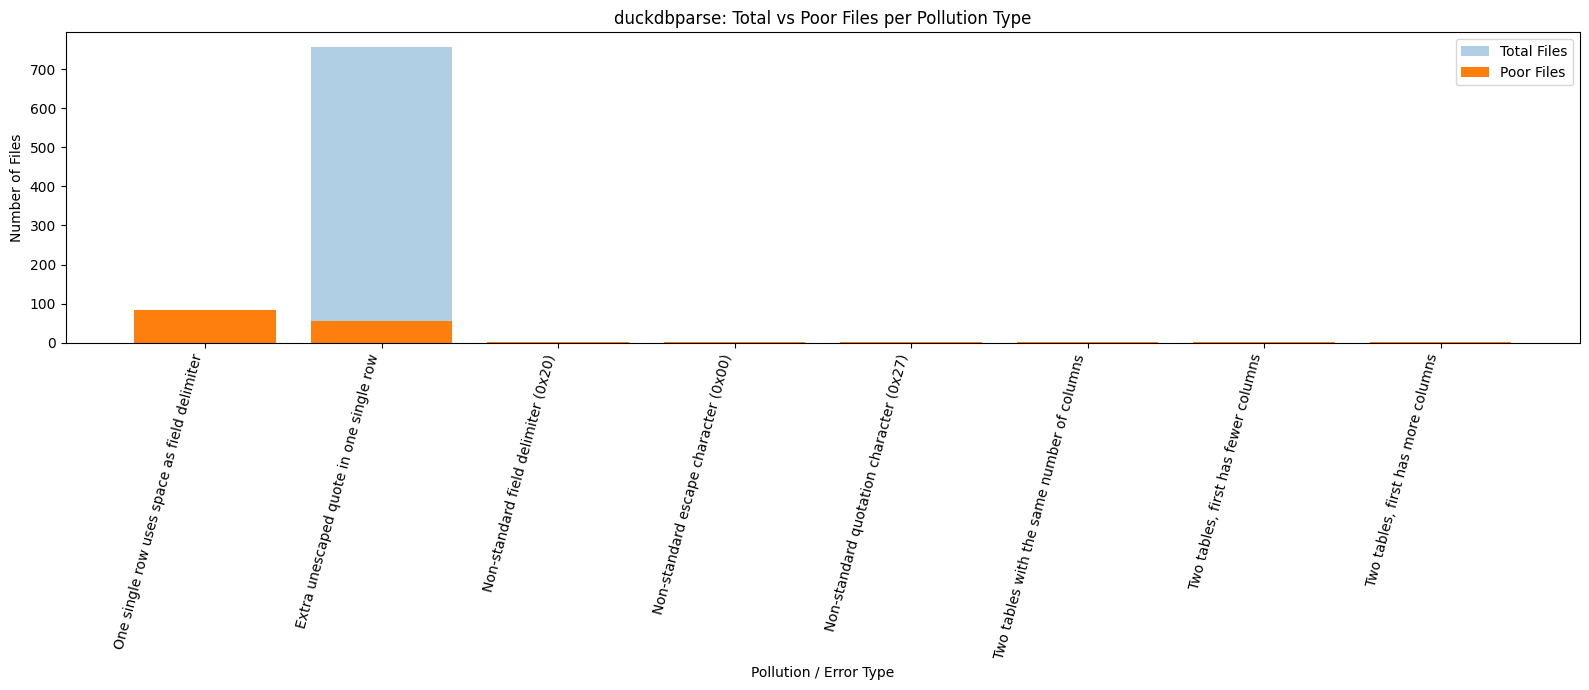

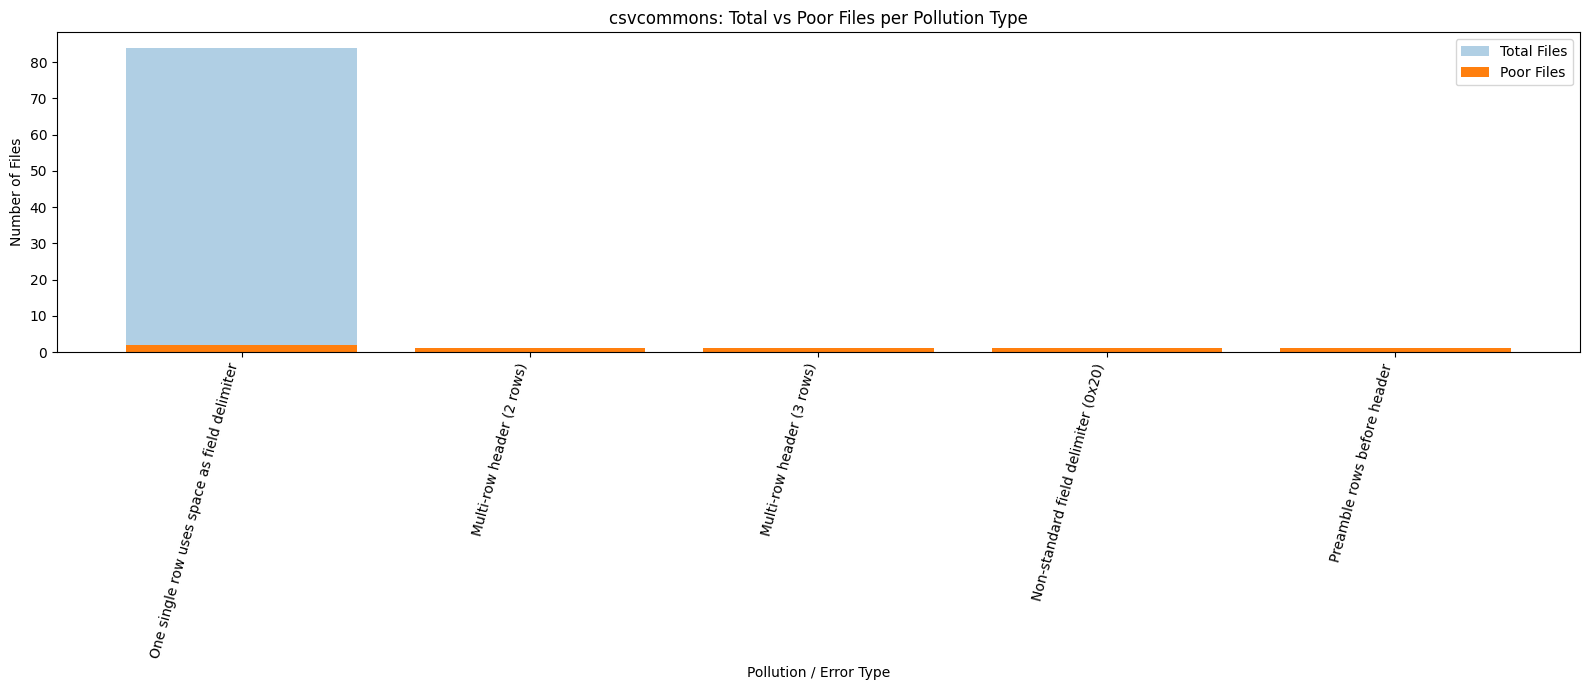

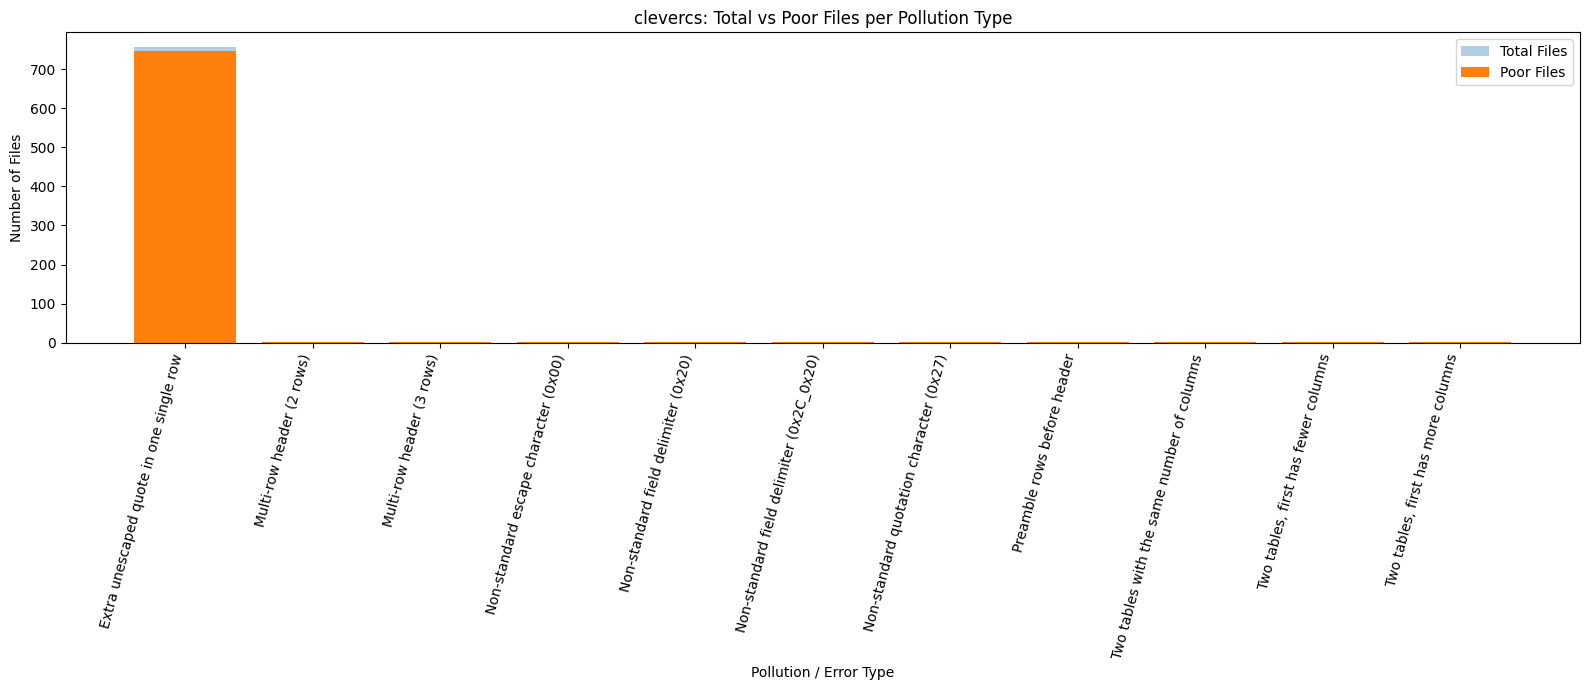

In [15]:
# Load CSV
df = pd.read_csv("sut_error_summary.csv")

# Remove aggregate rows
df = df[df["pollution_group"] != "ALL"]

# -----------------------------------
# Select Top 5 SUTs
# -----------------------------------
top_suts = (
    df.groupby("sut")["error_rate"]
    .mean()
    .sort_values()
    .head(5)
    .index
)

df = df[df["sut"].isin(top_suts)]

# -----------------------------------
# Create one histogram per SUT
# -----------------------------------
for sut in top_suts:

    sut_df = df[df["sut"] == sut].copy()

    # Remove rows where there are no poor files
    sut_df = sut_df[sut_df["poor_files"] > 0]

    # Sort by number of poor files
    sut_df = sut_df.sort_values("poor_files", ascending=False)

    # X positions
    x = np.arange(len(sut_df))

    # Figure
    plt.figure(figsize=(16, 7))

    # Background bars = total files
    plt.bar(
        x,
        sut_df["total_files"],
        alpha=0.35,
        label="Total Files"
    )

    # Foreground bars = poor files
    plt.bar(
        x,
        sut_df["poor_files"],
        label="Poor Files"
    )

    # Labels
    plt.xticks(
        x,
        sut_df["pollution_group"],
        rotation=75,
        ha="right"
    )

    plt.ylabel("Number of Files")
    plt.xlabel("Pollution / Error Type")

    plt.title(f"{sut}: Total vs Poor Files per Pollution Type")

    plt.legend()

    plt.tight_layout()
    plt.show()